# PRISM: Split Constitutions into Principles

In [1]:
import os
import sys
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

from dotenv import load_dotenv
from openai import OpenAI
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering

In [2]:
# Load environment variables from current directory .env and override existing ones, 
load_dotenv(".env", override=True)

# load api key from environment
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("OPENAI_API_KEY not found in .env file")

client = OpenAI(api_key=api_key)

In [3]:
df = pd.read_json("hf://datasets/HannahRoseKirk/prism-alignment/survey.jsonl", lines=True)

# Use the self-written constitution with respect to how participants want AI Language models to behave
self_written_ai_principles = df["system_string"].dropna().tolist()

print("Num constitutions:", len(self_written_ai_principles))
print("Example constitution snippet:", self_written_ai_principles[0][:200] if self_written_ai_principles else "N/A")

Num constitutions: 1500
Example constitution snippet: It needs to provide me with accurate information. It needs to inform me when it's guessing.


In [4]:
DISTANCE_TRESHOLD = 0.45  

decomposed_output = f"self_written_ai_principles_decomposed.json"

use_principles_for_ai = True

In [5]:
PROMPT_PATH = Path("principle_separation_prompt.txt")
DECOMPOSE_SYSTEM_PROMPT = PROMPT_PATH.read_text(encoding="utf-8").strip()

print("Loaded prompt from:", PROMPT_PATH)

Loaded prompt from: principle_separation_prompt.txt


In [6]:
def _parse_principles_lines(text: str) -> list:
    """Parse model output: one principle per line. Ignore empty lines."""
    lines = [ln.strip() for ln in text.splitlines()]
    lines = [ln for ln in lines if ln]
    return lines

def decompose_constitution(constitution: str) -> list:
    """Return 1–3 principles (strings) extracted from a constitution."""
    num_retries = 0
    max_retries = 5
    while True:
        try:
            messages = [{"role": "system", "content": DECOMPOSE_SYSTEM_PROMPT}]
            messages.append({"role": "user", "content": f"Input Constitution:\n{constitution}"})


            response = client.chat.completions.create(
                model="gpt-4.1-2025-04-14",
                messages=messages,
            )
            out = response.choices[0].message.content.strip()
            principles = _parse_principles_lines(out)

            # enforce 1–3 outputs, if the model returns more, truncate.
            if len(principles) == 0:
                return []
            return principles[:3]
        except Exception as e:
            print(f"Error: {e}. Retrying in 5 seconds...")
            num_retries += 1
            if num_retries >= max_retries:
                print("Max retries reached. Exiting.")
                sys.exit(1)
            time.sleep(5)

In [7]:
if os.path.exists(decomposed_output):
    print(f"Loading decomposed principles from {decomposed_output}")
    with open(decomposed_output, "r", encoding="utf-8") as f:
        decomposed = json.load(f)
else:
    print("No saved decomposition found. Generating now...")
    decomposed = []
    for c in tqdm(self_written_ai_principles, desc="Decomposing constitutions"):
        ps = decompose_constitution(c)
        decomposed.append({
            "constitution": c,
            "principles": ps
        })

    with open(decomposed_output, "w", encoding="utf-8") as f:
        json.dump(decomposed, f, indent=4, ensure_ascii=False)
    print(f"Saved decomposed mapping to {decomposed_output}")

generated_principles = []
for item in decomposed:
    for p in item.get("principles", []):
        if isinstance(p, str) and p.strip():
            generated_principles.append(p.strip())

print("Num generated principles:", len(generated_principles))
print("Example principle:", generated_principles[0] if generated_principles else "N/A")

Loading decomposed principles from self_written_ai_principles_decomposed.json
Num generated principles: 4115
Example principle: AI should provide accurate information.


In [8]:
def get_embedding(principle):
    num_retries = 0
    max_retries = 5
    while True:
        try:
            response = client.embeddings.create(
                input=principle,
                model="text-embedding-3-small"
            )
            return response.data[0].embedding
        except Exception as e:
            print(f"Error: {e}. Retrying in 5 seconds...")
            num_retries += 1
            if num_retries >= max_retries:
                print("Max retries reached. Exiting.")
                sys.exit(1)
            time.sleep(5)

In [9]:
if use_principles_for_ai:
    principles = generated_principles
    cluster_output = f'self_written_ai_principles_th={DISTANCE_TRESHOLD}_principles_clusters.json'
    summarized_principles_output = f'self_written_ai_principles_th={DISTANCE_TRESHOLD}_summarized.json'

In [10]:
emb_path = r"C:\Users\laras\OneDrive\Dokumente\duke_classes\icai_project\Principle-Elicitation\FairClustering\self_written_ai_principles_split_embeddings.npy"

if os.path.exists(emb_path):
    print(f"Loading embeddings from {emb_path}")
    embeddings = np.load(emb_path)
    embeddings = np.asarray(embeddings, dtype=np.float32)
else:
    print("No saved embeddings found. Computing embeddings now...")
    embeddings = []
    for p in tqdm(principles, desc="Computing embeddings"):
        embeddings.append(get_embedding(p))

    embeddings = np.vstack(embeddings)
    np.save(emb_path, embeddings)
    print(f"Saved embeddings to {emb_path}")

print("Embeddings shape:", embeddings.shape)

Loading embeddings from C:\Users\laras\OneDrive\Dokumente\duke_classes\icai_project\Principle-Elicitation\FairClustering\self_written_ai_principles_split_embeddings.npy
Embeddings shape: (4115, 1536)


In [11]:
def summarize_cluster(cluster, prompt, summary_prompt):
    num_retries = 0
    max_retries = 5
    while True:
        try:
            response = client.chat.completions.create(
                model="gpt-4.1-2025-04-14",
                messages=[
                    {"role": "system", "content": summary_prompt},
                    {"role": "user", "content": prompt}
                ],
            )
            summary = response.choices[0].message.content.strip()
            return({
                "cluster_id": cluster["cluster_id"],
                "summarized_principle": summary,
                "original_principles": cluster["principles"]
            })
            break
        except Exception as e:
            print(f"Error: {e}. Retrying in 5 seconds...")
            num_retries += 1
            if num_retries >= max_retries:
                print("Max retries reached. Exiting.")
                sys.exit(1)
            time.sleep(5)

In [12]:
#run a heirarchical clustering algorithm on the embeddings to group similar principles together
clustering_model = AgglomerativeClustering(n_clusters=None, linkage = 'average', metric = 'cosine', distance_threshold=DISTANCE_TRESHOLD)  # Adjust distance_threshold as needed
labels = clustering_model.fit_predict(embeddings)

#print number of clusters
num_clusters = len(set(labels))
print(f"Number of clusters: {num_clusters}")

#save clusters & principles to json
clusters = {}
for i, label in enumerate(labels):
    if label not in clusters:
        clusters[label] = []
    clusters[label].append(principles[i])

clusters_output = []
for i in range(len(clusters)):
    clusters_output.append({
        "cluster_id": i,
        "principles": clusters[i]
    })

with open(cluster_output, 'w', encoding="utf-8") as f:
    json.dump(clusters_output, f, indent=4, ensure_ascii=False)

print(f"Saved clusters to {cluster_output}")

Number of clusters: 54
Saved clusters to self_written_ai_principles_th=0.45_principles_clusters.json


(array([53.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  1.]),
 array([1.0000e+00, 1.2840e+02, 2.5580e+02, 3.8320e+02, 5.1060e+02,
        6.3800e+02, 7.6540e+02, 8.9280e+02, 1.0202e+03, 1.1476e+03,
        1.2750e+03, 1.4024e+03, 1.5298e+03, 1.6572e+03, 1.7846e+03,
        1.9120e+03, 2.0394e+03, 2.1668e+03, 2.2942e+03, 2.4216e+03,
        2.5490e+03, 2.6764e+03, 2.8038e+03, 2.9312e+03, 3.0586e+03,
        3.1860e+03, 3.3134e+03, 3.4408e+03, 3.5682e+03, 3.6956e+03,
        3.8230e+03]),
 <BarContainer object of 30 artists>)

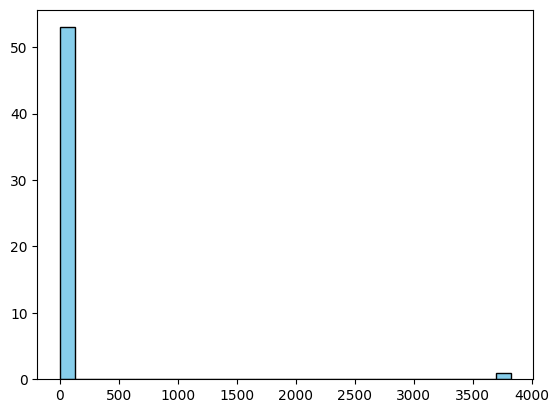

In [13]:
cluster_sizes = []
for cluster in clusters_output:
    cluster_sizes.append(len(cluster['principles']))


plt.hist(cluster_sizes, bins=30, color='skyblue', edgecolor='black')

In [14]:
# use gpt 4.1 to summarize each cluster of principles into a single principle that captures the general idea of each
with open('principle_summary_prompt.txt', 'r') as f:
    summary_prompt = f.read()
summary_prompt

'# Identity\n\nYou are an assistant that summarizes multiple similar principles, into a single principle for AI alignment. \nSome individual principles may be contextual, but the summary principles that you generate should capture the general concept that is\nshared between principles, without focusing on contextual elements, unless the contextual elements are shared between individual principles. \n\n# Instructions\n\n* Combine the presented principles into a single principle that captures the general idea and points of each of the presented principles.\n* Do not highlight contextual details of the presented principles in the summarized version.\n* Respond with only the summarized principle, do not add any formatting such as lists or dashes.\n* Rather than listing the components of individual principles, try to synthesize the main ideas.\n* Do not provide any additional commentary or thought process, only the summary principle.\n'

In [15]:
k = 5  # number of principles to include in the prompt

summarized_principles = []

for cluster in tqdm(clusters_output):

    # Calculate centroid of cluster embeddings

    cluster_embeddings = [embeddings[i] for i, label in enumerate(labels) if label == cluster["cluster_id"]]
    centroid = np.mean(cluster_embeddings, axis=0)

    # Find the k principles closest to the centroid
    distances = [np.linalg.norm(np.array(embedding) - centroid) for embedding in cluster_embeddings]
    closest_indices = np.argsort(distances)[:k]
    closest_principles = [cluster["principles"][i] for i in closest_indices]


    principles_text = "\n".join([f"{i+1}. {p}" for i, p in enumerate(closest_principles)])
    prompt = f"\n\nPrinciples:\n{principles_text}\n\nSummarized Principle:"
    
    summarized_principles.append(summarize_cluster(cluster, prompt, summary_prompt))

with open(summarized_principles_output, 'w') as f:
    json.dump(summarized_principles, f, indent=4)

100%|██████████████████████████████████████████████████████████████████████████████████| 54/54 [00:53<00:00,  1.00it/s]
